In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv(r"C:\Users\Abdelrahman\OneDrive\Desktop\Student_Dropout_Prediction\data\student_dropout_dataset_v3.csv")

In [3]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
df.tail()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [5]:
df.shape

(10000, 19)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

In [7]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [8]:
df["Family_Income"] = df["Family_Income"].fillna(df["Family_Income"].mean())

df["Study_Hours_per_Day"] = df["Study_Hours_per_Day"].fillna(df["Study_Hours_per_Day"].mean())

df["Stress_Index"] = df["Stress_Index"].fillna(df["Stress_Index"].mean())

In [9]:
df["Parental_Education"] = df["Parental_Education"].fillna(df["Parental_Education"].mode()[0])

In [10]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [11]:
df['GPA_Change'] = df['Semester_GPA'] - df['GPA']

In [12]:
df.drop(columns=["Student_ID", 'GPA', 'Semester_GPA'], inplace=True)
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,CGPA,Semester,Department,Parental_Education,Dropout,GPA_Change
0,22.1,Male,25000.000000,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.90,Year 1,Arts,High School,0,-0.06
1,20.7,Male,25000.000000,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.19,Year 3,Engineering,Bachelor,1,-0.08
2,22.4,Male,40183.000000,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.32,Year 1,Arts,Master,0,-0.36
3,24.4,Male,38377.247474,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.77,Year 1,CS,High School,1,-0.01
4,20.5,Female,25319.000000,Yes,4.190000,75.7,1,23.0,No,No,7.000000,0.87,Year 4,Business,Bachelor,0,-0.57


In [13]:
Q1 = df['Dropout'].quantile(0.25)  # First quartile (25th percentile)
Q3 = df['Dropout'].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile Range

# Define the range for non-outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
df_no_outliers = df[(df['Dropout'] >= lower_bound) & (df['Dropout'] <= upper_bound)]

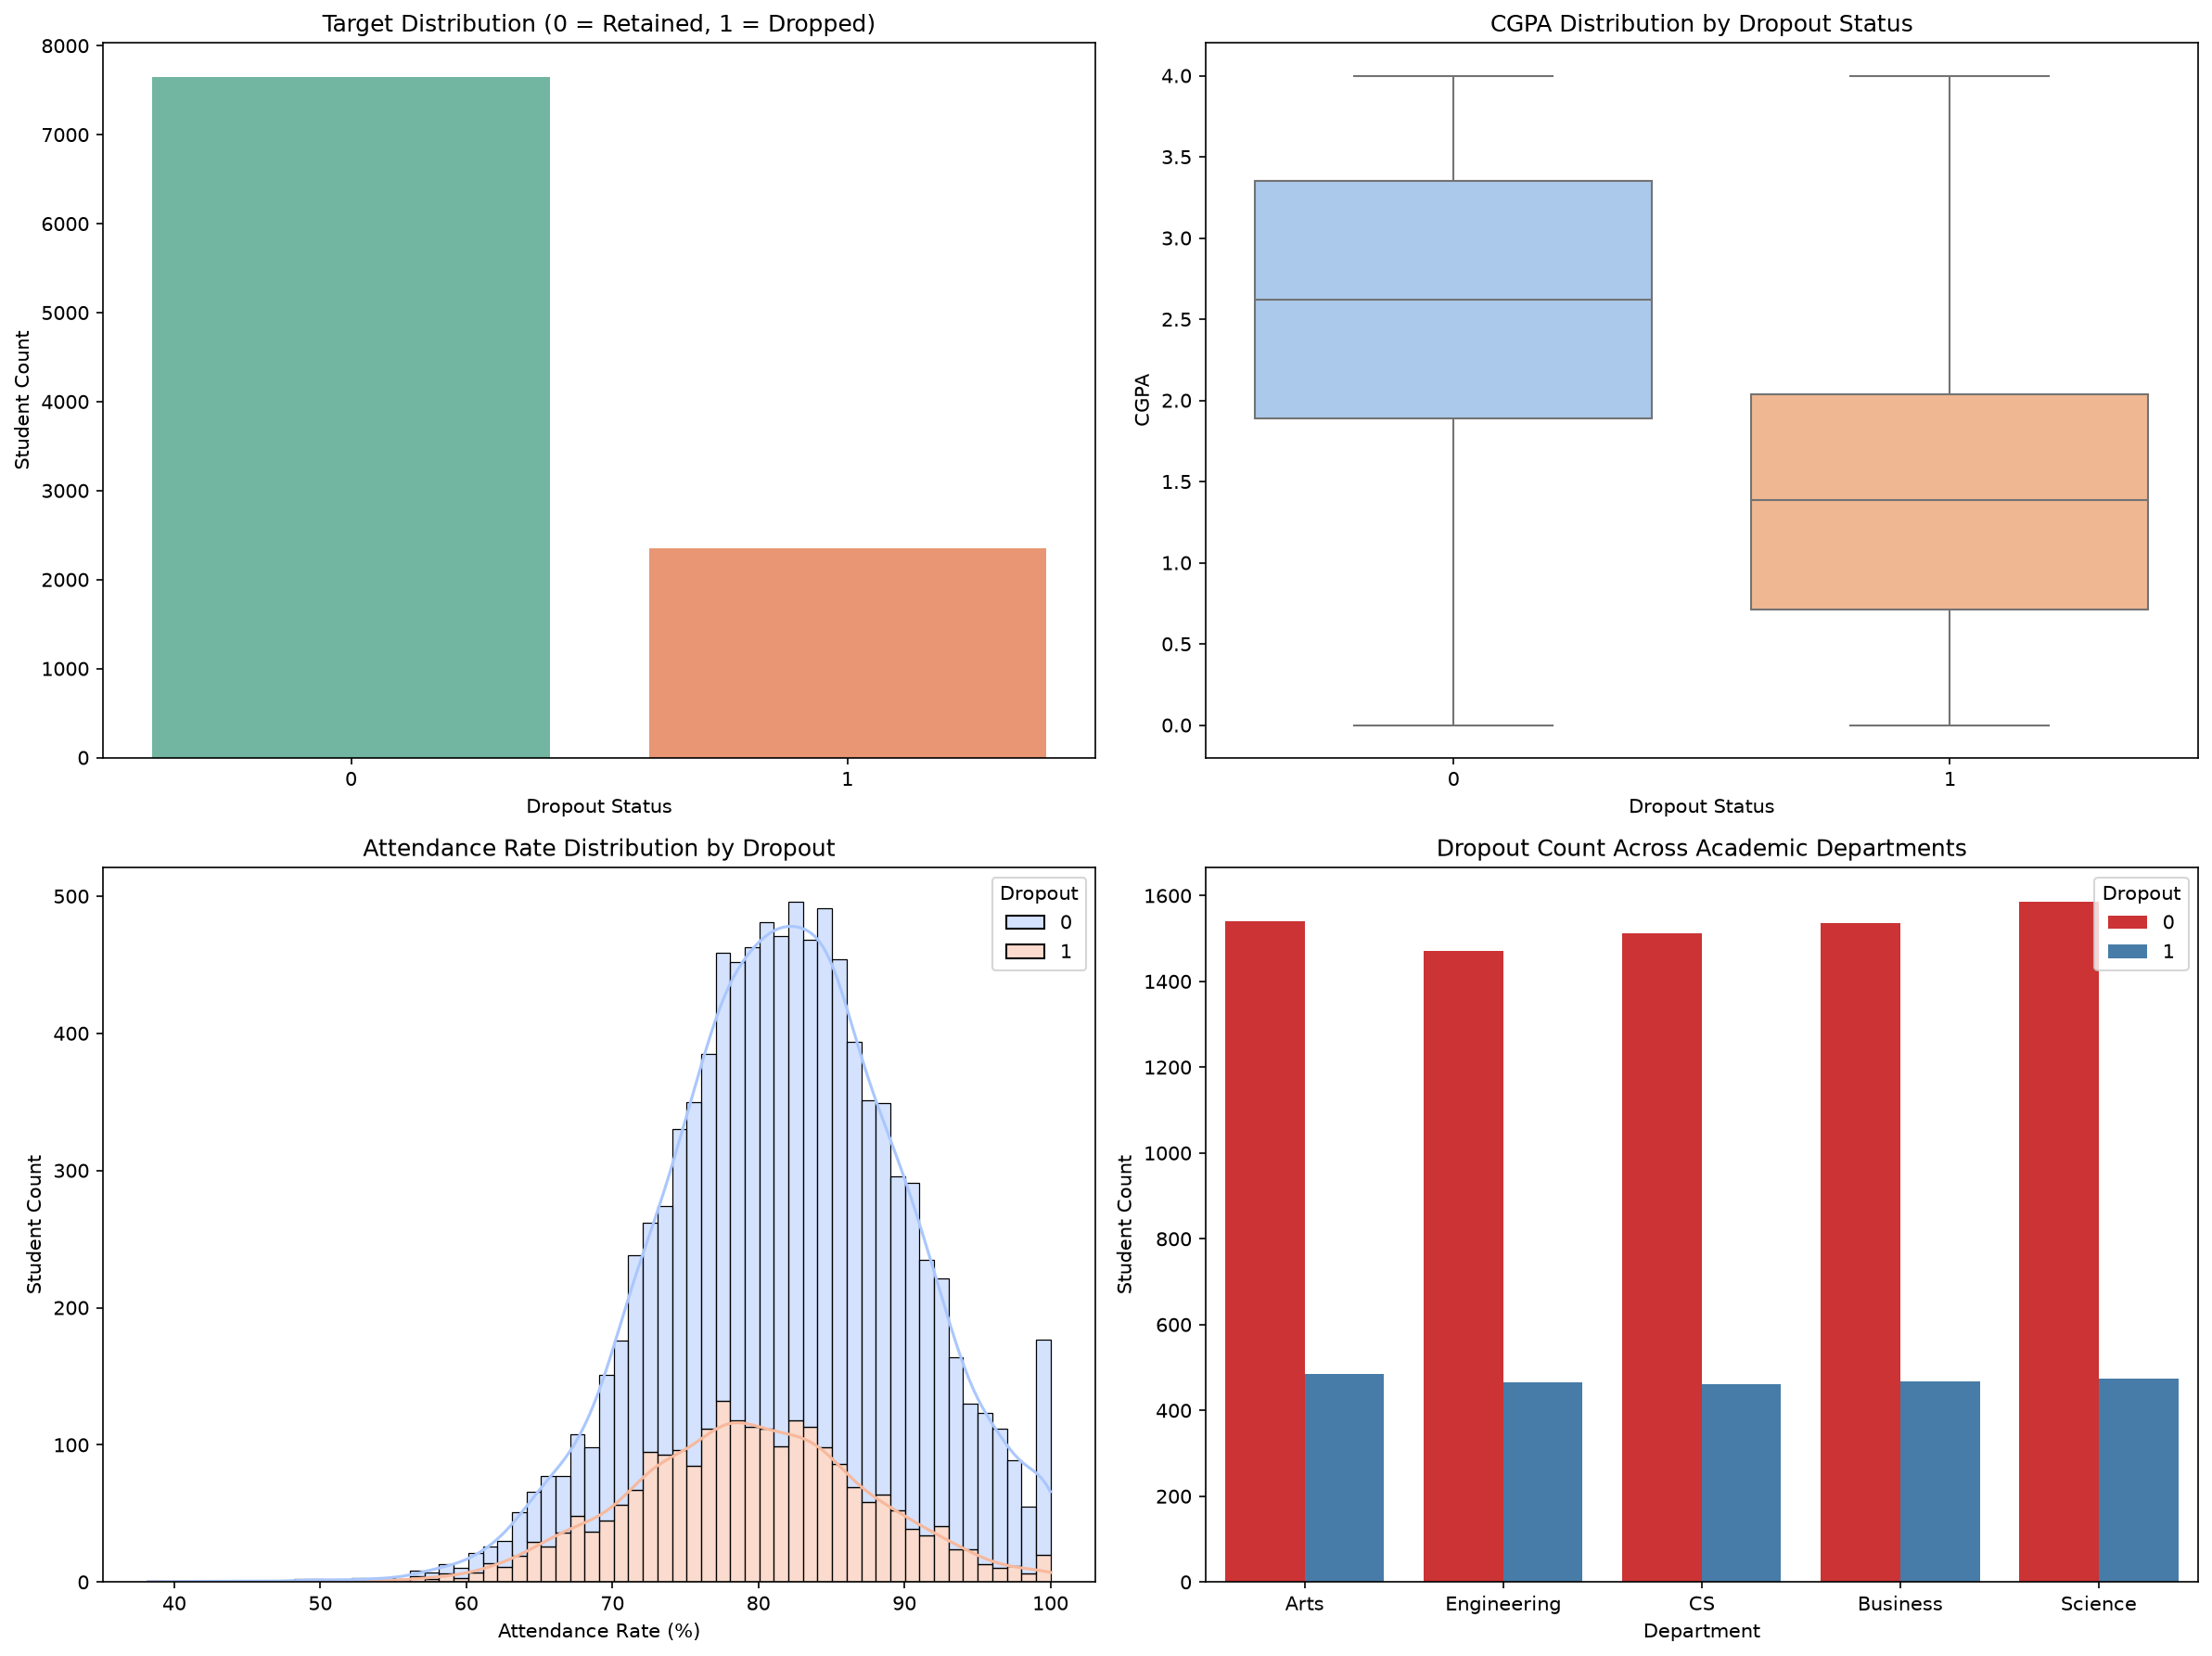

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
axes = axes.flatten()

sns.countplot(x='Dropout', data=df, ax=axes[0], palette='Set2').set(title='Target Distribution (0 = Retained, 1 = Dropped)', xlabel='Dropout Status', ylabel='Student Count')
sns.boxplot(x='Dropout', y='CGPA', data=df, ax=axes[1], palette='pastel').set(title='CGPA Distribution by Dropout Status', xlabel='Dropout Status', ylabel='CGPA')
sns.histplot(x='Attendance_Rate', hue='Dropout', data=df, ax=axes[2], kde=True, palette='coolwarm', multiple='stack').set(title='Attendance Rate Distribution by Dropout', xlabel='Attendance Rate (%)', ylabel='Student Count')
sns.countplot(x='Department', hue='Dropout', data=df, ax=axes[3], palette='Set1').set(title='Dropout Count Across Academic Departments', xlabel='Department', ylabel='Student Count')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [16]:
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,CGPA,Semester,Department,Parental_Education,Dropout,GPA_Change
0,22.1,Male,25000.000000,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.90,Year 1,Arts,High School,0,-0.06
1,20.7,Male,25000.000000,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.19,Year 3,Engineering,Bachelor,1,-0.08
2,22.4,Male,40183.000000,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.32,Year 1,Arts,Master,0,-0.36
3,24.4,Male,38377.247474,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.77,Year 1,CS,High School,1,-0.01
4,20.5,Female,25319.000000,Yes,4.190000,75.7,1,23.0,No,No,7.000000,0.87,Year 4,Business,Bachelor,0,-0.57


In [17]:
categorical_columns = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,CGPA,Semester,Department,Parental_Education,Dropout,GPA_Change
0,22.1,1,25000.000000,1,3.360000,86.1,2,20.4,1,0,5.500000,0.90,Year 1,Arts,High School,0,-0.06
1,20.7,1,25000.000000,1,4.300000,68.0,2,44.0,0,0,6.800000,1.19,Year 3,Engineering,Bachelor,1,-0.08
2,22.4,1,40183.000000,1,4.400000,70.9,0,48.9,1,0,5.500000,1.32,Year 1,Arts,Master,0,-0.36
3,24.4,1,38377.247474,1,4.014592,82.2,2,38.6,0,0,5.507147,1.77,Year 1,CS,High School,1,-0.01
4,20.5,0,25319.000000,1,4.190000,75.7,1,23.0,0,0,7.000000,0.87,Year 4,Business,Bachelor,0,-0.57


In [18]:
df_scaled = df.copy()
numerical_features = ['Age','Family_Income',"Study_Hours_per_Day","Assignment_Delay_Days","Travel_Time_Minutes","GPA_Change"]
scaler = StandardScaler()
df_scaled[numerical_features] = scaler.fit_transform(df_scaled[numerical_features])
df_scaled.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,CGPA,Semester,Department,Parental_Education,Dropout,GPA_Change
0,0.501911,1,-6.696591e-01,1,-5.184547e-01,86.1,0.149006,-0.820527,1,0,5.500000,0.90,Year 1,Arts,High School,0,-0.180632
1,-0.152386,1,-6.696591e-01,1,2.260514e-01,68.0,0.149006,1.159626,0,0,6.800000,1.19,Year 3,Engineering,Bachelor,1,-0.250621
2,0.642117,1,9.039518e-02,1,3.052542e-01,70.9,-1.338824,1.570759,1,0,5.500000,1.32,Year 1,Arts,Master,0,-1.230469
3,1.576826,1,3.642312e-16,1,-7.034620e-16,82.2,0.149006,0.706540,0,0,5.507147,1.77,Year 1,CS,High School,1,-0.005659
4,-0.245857,0,-6.536901e-01,1,1.389283e-01,75.7,-0.594909,-0.602374,0,0,7.000000,0.87,Year 4,Business,Bachelor,0,-1.965355


In [19]:
scaler = MinMaxScaler()
columns_to_scale = ['CGPA', 'Attendance_Rate', 'Stress_Index']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,CGPA,Semester,Department,Parental_Education,Dropout,GPA_Change
0,22.1,1,25000.000000,1,3.360000,0.775081,2,20.4,1,0,0.500000,0.2250,Year 1,Arts,High School,0,-0.06
1,20.7,1,25000.000000,1,4.300000,0.482201,2,44.0,0,0,0.644444,0.2975,Year 3,Engineering,Bachelor,1,-0.08
2,22.4,1,40183.000000,1,4.400000,0.529126,0,48.9,1,0,0.500000,0.3300,Year 1,Arts,Master,0,-0.36
3,24.4,1,38377.247474,1,4.014592,0.711974,2,38.6,0,0,0.500794,0.4425,Year 1,CS,High School,1,-0.01
4,20.5,0,25319.000000,1,4.190000,0.606796,1,23.0,0,0,0.666667,0.2175,Year 4,Business,Bachelor,0,-0.57


In [20]:
encoder = OneHotEncoder(sparse_output=False)

df[encoder.get_feature_names_out(['Semester', 'Department', 'Parental_Education'])] = encoder.fit_transform(df[['Semester', 'Department', 'Parental_Education']])

df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,...,Semester_Year 4,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,22.1,1,25000.000000,1,3.360000,0.775081,2,20.4,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20.7,1,25000.000000,1,4.300000,0.482201,2,44.0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,22.4,1,40183.000000,1,4.400000,0.529126,0,48.9,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,24.4,1,38377.247474,1,4.014592,0.711974,2,38.6,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,20.5,0,25319.000000,1,4.190000,0.606796,1,23.0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [21]:
df.drop(columns=['Semester', 'Department', 'Parental_Education'], inplace=True)
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,...,Semester_Year 4,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,22.1,1,25000.000000,1,3.360000,0.775081,2,20.4,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20.7,1,25000.000000,1,4.300000,0.482201,2,44.0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,22.4,1,40183.000000,1,4.400000,0.529126,0,48.9,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,24.4,1,38377.247474,1,4.014592,0.711974,2,38.6,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,20.5,0,25319.000000,1,4.190000,0.606796,1,23.0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
X = df.drop(columns=["Dropout"])
y = df["Dropout"]
X.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,...,Semester_Year 4,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,22.1,1,25000.000000,1,3.360000,0.775081,2,20.4,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20.7,1,25000.000000,1,4.300000,0.482201,2,44.0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,22.4,1,40183.000000,1,4.400000,0.529126,0,48.9,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,24.4,1,38377.247474,1,4.014592,0.711974,2,38.6,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,20.5,0,25319.000000,1,4.190000,0.606796,1,23.0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (8000, 26)
Test : (2000, 26)


In [24]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [25]:
y_pred = rf.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7925


In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1323  222]
 [ 193  262]]


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1545
           1       0.54      0.58      0.56       455

    accuracy                           0.79      2000
   macro avg       0.71      0.72      0.71      2000
weighted avg       0.80      0.79      0.79      2000



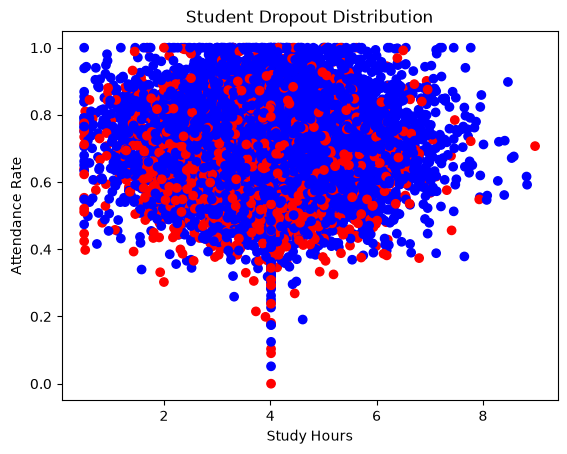

In [29]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Study_Hours_per_Day"],
    df["Attendance_Rate"],
    c=df["Dropout"],
    cmap="bwr"  
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance Rate")
plt.title("Student Dropout Distribution")

plt.show()